In [ ]:
import numpy as np

class NeuralNetwork:
    def __init__(self):
        # Seed for reproducibility
        np.random.seed(42)

        # Initialize Weights and Biases
        # Input (3) -> Hidden 1 (4)
        self.W1 = np.random.randn(3, 4) * 0.1
        self.b1 = np.zeros((1, 4))

        # Hidden 1 (4) -> Hidden 2 (3)
        self.W2 = np.random.randn(4, 3) * 0.1
        self.b2 = np.zeros((1, 3))

        # Hidden 2 (3) -> Output (3)
        self.W3 = np.random.randn(3, 3) * 0.1
        self.b3 = np.zeros((1, 3))

    # Activation Functions
    def relu(self, Z):
        return np.maximum(0, Z)

    def tanh(self, Z):
        return np.tanh(Z)

    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def forward_propagation(self, X):
        self.X = X # Store input for backprop

        # Layer 1: Input to Hidden 1 (ReLU)
        self.Z1 = np.dot(self.X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)

        # Layer 2: Hidden 1 to Hidden 2 (Tanh)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.tanh(self.Z2)

        # Layer 3: Hidden 2 to Output (Softmax)
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = self.softmax(self.Z3)

        return self.A3

    def calculate_loss(self, y_true):
        # Using self.A3 from forward pass
        epsilon = 1e-15
        y_pred = np.clip(self.A3, epsilon, 1 - epsilon)
        loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
        return loss

    def backward(self, Y, learning_rate):
        m = Y.shape[0]

        # Output Layer Gradients (Layer 3)
        dZ3 = self.A3 - Y
        dW3 = (1/m) * np.dot(self.A2.T, dZ3)
        db3 = (1/m) * np.sum(dZ3, axis=0, keepdims=True)

        # Hidden Layer 2 Gradients (Layer 2)
        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * (1 - np.power(self.A2, 2)) # Tanh derivative
        dW2 = (1/m) * np.dot(self.A1.T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

        # Hidden Layer 1 Gradients (Layer 1)
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * (self.Z1 > 0) # ReLU derivative
        dW1 = (1/m) * np.dot(self.X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

        # Update Parameters
        self.W3 -= learning_rate * dW3
        self.b3 -= learning_rate * db3
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def train(self, X, Y, epochs=200, learning_rate=0.1, tol=1e-4):
        prev_loss = float('inf')

        print(f"{'Epoch':<10} | {'Loss':<12} | {'Accuracy':<10}")
        print("-" * 38)

        for epoch in range(1, epochs + 1):
            # Forward pass
            probs = self.forward_propagation(X)

            # Loss and Accuracy
            loss = self.calculate_loss(Y)
            predictions = np.argmax(probs, axis=1)
            targets = np.argmax(Y, axis=1)
            accuracy = np.mean(predictions == targets) * 100

            # Backprop
            self.backward(Y, learning_rate)

            # Print logs every 20 epochs
            if epoch % 20 == 0 or epoch == 1:
                print(f"{epoch:<10} | {loss:<12.6f} | {accuracy:<10.2f}%")

            # Convergence check
            if abs(prev_loss - loss) < tol:
                print(f"\nConverged at epoch {epoch} (Loss change < {tol})")
                break

            prev_loss = loss

    def predict(self, X):
        probs = self.forward_propagation(X)
        return np.argmax(probs, axis=1)



# Initialize and Run
nn = NeuralNetwork()
output = nn.forward_propagation(X)

print("Predictions (Probabilities per class):")
print(output)


Predictions (Probabilities per class):
[[0.33200115 0.33350621 0.33449264]
 [0.33260024 0.33394721 0.33345254]
 [0.3342617  0.33169817 0.33404012]
 [0.33263645 0.33399648 0.33336708]
 [0.3336086  0.33273803 0.33365338]]


In [ ]:
#B
def calculate_loss(y_true, y_pred):
    """
    y_true: Ground truth labels (one-hot encoded)
    y_pred: Predicted probabilities from softmax
    """
    # Clip y_pred to prevent log(0) which results in infinity
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    # Calculate Cross-Entropy
    # We multiply element-wise, sum across rows, then take the mean
    loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    return loss

# --- Application ---

# Dataset Y provided
Y = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
    [1, 0, 0],
    [0, 1, 0]
])

# Using the 'output' from the Forward Propagation step in Part A
current_loss = calculate_loss(Y, output)

print(f"Categorical Cross-Entropy Loss: {current_loss:.4f}")

Categorical Cross-Entropy Loss: 1.0994


In [ ]:
model = NeuralNetwork()
model.train(X, Y, epochs=200, learning_rate=0.1)

Epoch      | Loss         | Accuracy  
--------------------------------------
1          | 1.099398     | 20.00     %
20         | 1.068226     | 60.00     %
40         | 1.057523     | 60.00     %
60         | 1.052866     | 60.00     %
80         | 1.048911     | 60.00     %
100        | 1.041853     | 60.00     %
120        | 1.022425     | 60.00     %
140        | 0.947775     | 80.00     %
160        | 0.742365     | 80.00     %
180        | 0.562864     | 80.00     %
200        | 0.482372     | 80.00     %


In [ ]:
import numpy as np

# Assuming the NeuralNetwork class from previous steps is defined
# and NeuralNetworkAdaptive inherits from it.
# Let's put it all together into a final runnable script.

class NeuralNetworkFinal:
    def __init__(self):
        np.random.seed(42)
        # Using 0.1 scaling for stability
        self.W1 = np.random.randn(3, 4) * 0.1
        self.b1 = np.zeros((1, 4))
        self.W2 = np.random.randn(4, 3) * 0.1
        self.b2 = np.zeros((1, 3))
        self.W3 = np.random.randn(3, 3) * 0.1
        self.b3 = np.zeros((1, 3))

    def relu(self, Z): return np.maximum(0, Z)
    def tanh(self, Z): return np.tanh(Z)
    def sigmoid(self, Z): return 1 / (1 + np.exp(-Z))
    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def calculate_loss(self, Y_true, Y_pred):
        return -np.mean(np.sum(Y_true * np.log(Y_pred + 1e-15), axis=1))

    def train_variant(self, X, Y, mode='case1', epochs=200, learning_rate=0.1):
        # Reset weights to ensure a fair "apples-to-apples" comparison
        np.random.seed(42)
        self.W1 = np.random.randn(3, 4) * 0.1
        self.W2 = np.random.randn(4, 3) * 0.1
        self.W3 = np.random.randn(3, 3) * 0.1

        prev_loss = float('inf')

        print(f"\n--- Running {mode.upper()} ---")
        for epoch in range(1, epochs + 1):
            # Forward Pass
            self.Z1 = np.dot(X, self.W1) + self.b1
            self.A1 = self.relu(self.Z1) if mode == 'case1' else self.sigmoid(self.Z1)

            self.Z2 = np.dot(self.A1, self.W2) + self.b2
            self.A2 = self.tanh(self.Z2) if mode == 'case1' else self.sigmoid(self.Z2)

            self.Z3 = np.dot(self.A2, self.W3) + self.b3
            self.A3 = self.softmax(self.Z3)

            # Loss
            loss = self.calculate_loss(Y, self.A3)

            # Backward Pass
            m = X.shape[0]
            dZ3 = self.A3 - Y
            dW3 = (1/m) * np.dot(self.A2.T, dZ3)
            db3 = (1/m) * np.sum(dZ3, axis=0, keepdims=True)

            dA2 = np.dot(dZ3, self.W3.T)
            dZ2 = dA2 * (1 - np.power(self.A2, 2)) if mode == 'case1' else dA2 * (self.A2 * (1 - self.A2))

            dW2 = (1/m) * np.dot(self.A1.T, dZ2)
            db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, self.W2.T)
            dZ1 = dA1 * (self.Z1 > 0) if mode == 'case1' else dA1 * (self.A1 * (1 - self.A1))

            dW1 = (1/m) * np.dot(X.T, dZ1)
            db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

            # Updates
            self.W3 -= learning_rate * dW3
            self.b3 -= learning_rate * db3
            self.W2 -= learning_rate * dW2
            self.b2 -= learning_rate * db2
            self.W1 -= learning_rate * dW1
            self.b1 -= learning_rate * db1

            if epoch % 40 == 0 or epoch == 1:
                acc = np.mean(np.argmax(self.A3, axis=1) == np.argmax(Y, axis=1)) * 100
                print(f"Epoch {epoch:3} | Loss: {loss:.4f} | Accuracy: {acc:.1f}%")

            # Convergence check
            if abs(prev_loss - loss) < 1e-4:
                print(f"Converged at epoch {epoch}")
                break
            prev_loss = loss
        return loss, np.mean(np.argmax(self.A3, axis=1) == np.argmax(Y, axis=1)) * 100

# --- Execution ---
X_data = np.array([[1, 2, -1], [0, 1, 2], [2, -1, 1], [-1, 1, 0], [1, 0, 1]])
Y_data = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 0, 0], [0, 1, 0]])

model = NeuralNetworkFinal()

# Run Case 1
loss1, acc1 = model.train_variant(X_data, Y_data, mode='case1')

# Run Case 2
loss2, acc2 = model.train_variant(X_data, Y_data, mode='case2')

print("\n" + "="*30)
print("FINAL COMPARISON")
print(f"Case 1 (ReLU+Tanh): Final Loss {loss1:.4f}, Accuracy {acc1:.1f}%")
print(f"Case 2 (Sigmoid):   Final Loss {loss2:.4f}, Accuracy {acc2:.1f}%")
print("="*30)


--- Running CASE1 ---
Epoch   1 | Loss: 1.0994 | Accuracy: 20.0%
Epoch  40 | Loss: 1.0575 | Accuracy: 60.0%
Epoch  80 | Loss: 1.0489 | Accuracy: 60.0%
Epoch 120 | Loss: 1.0224 | Accuracy: 60.0%
Epoch 160 | Loss: 0.7424 | Accuracy: 80.0%
Epoch 200 | Loss: 0.4824 | Accuracy: 80.0%

--- Running CASE2 ---
Epoch   1 | Loss: 1.0591 | Accuracy: 40.0%
Converged at epoch 15

FINAL COMPARISON
Case 1 (ReLU+Tanh): Final Loss 0.4824, Accuracy 80.0%
Case 2 (Sigmoid):   Final Loss 1.0555, Accuracy 40.0%


part f

In [ ]:
import numpy as np

class NeuralNetwork:
    def __init__(self):
        np.random.seed(42)
        # Initialization
        self.W1 = np.random.randn(3, 4) * 0.1
        self.b1 = np.zeros((1, 4))
        self.W2 = np.random.randn(4, 3) * 0.1
        self.b2 = np.zeros((1, 3))
        self.W3 = np.random.randn(3, 3) * 0.1
        self.b3 = np.zeros((1, 3))

    def relu(self, Z): return np.maximum(0, Z)
    def tanh(self, Z): return np.tanh(Z)
    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def forward_propagation(self, X):
        self.X = X
        self.Z1 = np.dot(self.X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.tanh(self.Z2)
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = self.softmax(self.Z3)
        return self.A3

    def calculate_loss(self, y_true):
        epsilon = 1e-15
        y_pred = np.clip(self.A3, epsilon, 1 - epsilon)
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    def backward(self, Y, learning_rate):
        m = Y.shape[0]
        # Gradients
        dZ3 = self.A3 - Y
        self.dW3 = (1/m) * np.dot(self.A2.T, dZ3)
        self.db3 = (1/m) * np.sum(dZ3, axis=0, keepdims=True)

        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * (1 - np.power(self.A2, 2))
        self.dW2 = (1/m) * np.dot(self.A1.T, dZ2)
        self.db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * (self.Z1 > 0)
        self.dW1 = (1/m) * np.dot(self.X.T, dZ1)
        self.db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

        # Update
        self.W3 -= learning_rate * self.dW3
        self.b3 -= learning_rate * self.db3
        self.W2 -= learning_rate * self.dW2
        self.b2 -= learning_rate * self.db2
        self.W1 -= learning_rate * self.dW1
        self.b1 -= learning_rate * self.db1

    def gradient_check(self, X, Y, epsilon=1e-7):
        """Part f: Gradient Checking for W3[0,0]"""
        # 1. Analytical Gradient
        self.forward_propagation(X)
        self.backward(Y, learning_rate=0) # Get dW3 without changing weights
        ana_grad = self.dW3[0, 0]

        # 2. Numerical Gradient
        orig_w = self.W3[0, 0]

        self.W3[0, 0] = orig_w + epsilon
        self.forward_propagation(X)
        l_plus = self.calculate_loss(Y)

        self.W3[0, 0] = orig_w - epsilon
        self.forward_propagation(X)
        l_minus = self.calculate_loss(Y)

        self.W3[0, 0] = orig_w # Reset
        num_grad = (l_plus - l_minus) / (2 * epsilon)

        # 3. Errors
        abs_err = np.abs(ana_grad - num_grad)
        rel_err = abs_err / (np.abs(ana_grad) + np.abs(num_grad) + 1e-15)

        return ana_grad, num_grad, abs_err, rel_err


    def train(self, X, Y, epochs=200, learning_rate=0.1, tol=1e-4):
        prev_loss = float('inf')

        print(f"{'Epoch':<10} | {'Loss':<12} | {'Accuracy':<10}")
        print("-" * 38)

        for epoch in range(1, epochs + 1):
            # Forward pass
            probs = self.forward_propagation(X)

            # Loss and Accuracy
            loss = self.calculate_loss(Y)
            predictions = np.argmax(probs, axis=1)
            targets = np.argmax(Y, axis=1)
            accuracy = np.mean(predictions == targets) * 100

            # Backprop
            self.backward(Y, learning_rate)

            # Print logs every 20 epochs
            if epoch % 20 == 0 or epoch == 1:
                print(f"{epoch:<10} | {loss:<12.6f} | {accuracy:<10.2f}%")

            # Convergence check
            if abs(prev_loss - loss) < tol:
                print(f"\nConverged at epoch {epoch} (Loss change < {tol})")
                break

            prev_loss = loss


# --- Run everything ---
X = np.array([[1, 2, -1], [0, 1, 2], [2, -1, 1], [-1, 1, 0], [1, 0, 1]])
Y = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 0, 0], [0, 1, 0]])

nn = NeuralNetwork()
# Perform Gradient Check before training
ana, num, abs_e, rel_e = nn.gradient_check(X, Y)

print("--- Gradient Check Results ---")
print(f"Analytical: {ana:.8f}")
print(f"Numerical:  {num:.8f}")
print(f"Abs Error:  {abs_e:.4e}")
print(f"Rel Error:  {rel_e:.4e}")
print("-" * 30)

# Now Train
nn.train(X, Y, epochs=200, learning_rate=0.1)

--- Gradient Check Results ---
Analytical: 0.00573659
Numerical:  0.00573658
Abs Error:  7.3735e-10
Rel Error:  6.4267e-08
------------------------------
Epoch      | Loss         | Accuracy  
--------------------------------------
1          | 1.099398     | 20.00     %
20         | 1.068226     | 60.00     %
40         | 1.057523     | 60.00     %
60         | 1.052866     | 60.00     %
80         | 1.048911     | 60.00     %
100        | 1.041853     | 60.00     %
120        | 1.022425     | 60.00     %
140        | 0.947775     | 80.00     %
160        | 0.742365     | 80.00     %
180        | 0.562864     | 80.00     %
200        | 0.482372     | 80.00     %


In [ ]:
import time
from sklearn.neural_network import MLPClassifier
import numpy as np

# Dataset
X = np.array([[1, 2, -1], [0, 1, 2], [2, -1, 1], [-1, 1, 0], [1, 0, 1]])
Y = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 0, 0], [0, 1, 0]])
# Scikit-learn expects class labels, not one-hot encoding for the fit method
y_labels = np.argmax(Y, axis=1)

# Initialize MLPClassifier
# Architecture: Hidden 1 (4, ReLU), Hidden 2 (3, Tanh)
# Note: Sklearn's MLPClassifier uses the same activation for all hidden layers.
# To match your specific "ReLU then Tanh" requirement exactly, we use PyTorch logic below
# but for a standard library comparison, we'll use a consistent Tanh architecture here.
mlp = MLPClassifier(
    hidden_layer_sizes=(4, 3),
    activation='tanh',
    solver='sgd',
    learning_rate_init=0.1,
    max_iter=200,
    tol=1e-4,
    random_state=42
)

# Measure Training Speed
start_time = time.time()
mlp.fit(X, y_labels)
end_time = time.time()

# Results
library_acc = mlp.score(X, y_labels) * 100
library_speed = end_time - start_time

print(f"Library Accuracy: {library_acc}%")
print(f"Training Time: {library_speed:.6f} seconds")
print(f"Final Loss: {mlp.loss_:.6f}")

Library Accuracy: 100.0%
Training Time: 0.133924 seconds
Final Loss: 0.005018


part 2

In [ ]:
import numpy as np
from sklearn.datasets import load_iris

# --- Part 2: Loading Data ---
iris = load_iris()
X_raw = iris.data    # Shape: (150, 4)
y_raw = iris.target  # Shape: (150,)

# --- Part a: Preprocessing (Manual Only) ---

def manual_normalize(X):
    """
    Min-Max Normalization: (X - min) / (max - min)
    Scales features to [0, 1] range.
    """
    x_min = np.min(X, axis=0)
    x_max = np.max(X, axis=0)
    X_norm = (X - x_min) / (x_max - x_min)
    return X_norm

def manual_one_hot(y):
    """
    Converts integer labels to one-hot encoded vectors.
    Example: 2 -> [0, 0, 1]
    """
    num_classes = len(np.unique(y))
    one_hot = np.zeros((y.size, num_classes))
    # Advanced indexing to set 1s
    one_hot[np.arange(y.size), y] = 1
    return one_hot

# Apply Preprocessing
X = manual_normalize(X_raw)
Y = manual_one_hot(y_raw)

# Shuffle the dataset (Important for Iris as it is ordered by class)
indices = np.arange(X.shape[0])
np.random.seed(42)
np.random.shuffle(indices)

X = X[indices]
Y = Y[indices]

print(f"Dataset Loaded: {X.shape[0]} samples, {X.shape[1]} features")
print("\nFirst 5 normalized samples (X):")
print(X[:5])
print("\nFirst 5 one-hot labels (Y):")
print(Y[:5])

Dataset Loaded: 150 samples, 4 features

First 5 normalized samples (X):
[[0.5        0.33333333 0.62711864 0.45833333]
 [0.38888889 0.75       0.11864407 0.08333333]
 [0.94444444 0.25       1.         0.91666667]
 [0.47222222 0.375      0.59322034 0.58333333]
 [0.69444444 0.33333333 0.6440678  0.54166667]]

First 5 one-hot labels (Y):
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class IrisNeuralNetwork:
    def __init__(self):
        np.random.seed(42)
        # UPDATED: Input (4) -> Hidden 1 (4)
        self.W1 = np.random.randn(4, 4) * 0.1
        self.b1 = np.zeros((1, 4))

        # Hidden 1 (4) -> Hidden 2 (3)
        self.W2 = np.random.randn(4, 3) * 0.1
        self.b2 = np.zeros((1, 3))

        # Hidden 2 (3) -> Output (3)
        self.W3 = np.random.randn(3, 3) * 0.1
        self.b3 = np.zeros((1, 3))

    def relu(self, Z): return np.maximum(0, Z)
    def tanh(self, Z): return np.tanh(Z)
    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def forward_propagation(self, X):
        self.X = X
        self.Z1 = np.dot(self.X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.tanh(self.Z2)
        self.Z3 = np.dot(self.A2, self.W3) + self.b3
        self.A3 = self.softmax(self.Z3)
        return self.A3

    def calculate_loss(self, y_true):
        epsilon = 1e-15
        y_pred = np.clip(self.A3, epsilon, 1 - epsilon)
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    def backward(self, Y, learning_rate):
        m = Y.shape[0]
        dZ3 = self.A3 - Y
        dW3 = (1/m) * np.dot(self.A2.T, dZ3)
        db3 = (1/m) * np.sum(dZ3, axis=0, keepdims=True)

        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * (1 - np.power(self.A2, 2))
        dW2 = (1/m) * np.dot(self.A1.T, dZ2)
        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * (self.Z1 > 0)
        dW1 = (1/m) * np.dot(self.X.T, dZ1)
        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

        # Updates
        self.W3 -= learning_rate * dW3
        self.b3 -= learning_rate * db3
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

Epoch      | Loss         | Train Acc 
----------------------------------------
1          | 1.099667     | 30.83     %
50         | 1.097418     | 35.83     %
100        | 1.097013     | 35.83     %
150        | 1.096752     | 35.83     %
200        | 1.096300     | 35.83     %
250        | 1.095242     | 35.83     %
300        | 1.092092     | 35.83     %
350        | 1.078447     | 35.83     %
400        | 0.986659     | 67.50     %
450        | 0.697422     | 70.83     %
500        | 0.546101     | 76.67     %
----------------------------------------
FINAL TRAINING ACCURACY: 76.67%
FINAL TEST ACCURACY:     70.00%


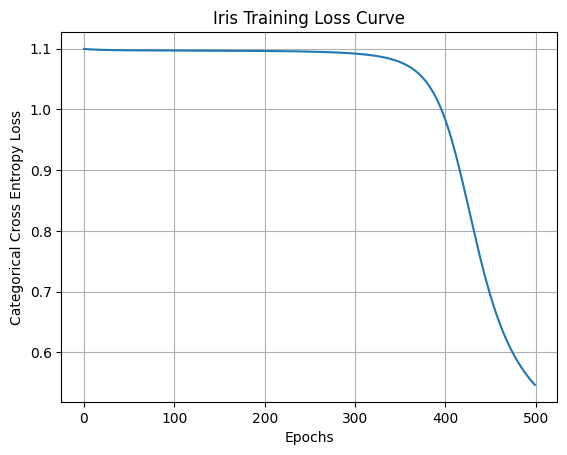

In [ ]:
# 1. Split Data (Manual 80/20 split)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# 2. Initialize Model
model = IrisNeuralNetwork()
epochs = 500
lr = 0.1
loss_history = []

print(f"{'Epoch':<10} | {'Loss':<12} | {'Train Acc':<10}")
print("-" * 40)

# 3. Training Loop
for epoch in range(1, epochs + 1):
    probs = model.forward_propagation(X_train)
    loss = model.calculate_loss(Y_train)
    loss_history.append(loss)

    model.backward(Y_train, lr)

    if epoch % 50 == 0 or epoch == 1:
        train_acc = np.mean(np.argmax(probs, axis=1) == np.argmax(Y_train, axis=1)) * 100
        print(f"{epoch:<10} | {loss:<12.6f} | {train_acc:<10.2f}%")

# 4. Required Outputs
# Final Training Accuracy
train_probs = model.forward_propagation(X_train)
final_train_acc = np.mean(np.argmax(train_probs, axis=1) == np.argmax(Y_train, axis=1)) * 100

# Test Accuracy
test_probs = model.forward_propagation(X_test)
final_test_acc = np.mean(np.argmax(test_probs, axis=1) == np.argmax(Y_test, axis=1)) * 100

print("-" * 40)
print(f"FINAL TRAINING ACCURACY: {final_train_acc:.2f}%")
print(f"FINAL TEST ACCURACY:     {final_test_acc:.2f}%")

# 5. Plot Loss Curve
plt.plot(loss_history)
plt.title("Iris Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Categorical Cross Entropy Loss")
plt.grid(True)
plt.show()